# A quick look at the data

Two tables in a SQLite file: one row per order line, and a small lookup of sellers. Prices are in Brazilian Real (`R$`). Today's date, for anything relative like "last month", is 1 September 2018. That's it. Let's open it up and see what we're dealing with.

## Open the database

Two tables: `items` holds every order line ever placed. `sellers` is the phone-book of who they came from.

In [1]:
import sqlite3
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DB   = ROOT / 'data' / 'olist_seller.sqlite'

with sqlite3.connect(DB) as conn:
    items   = pd.read_sql('SELECT * FROM items',   conn, parse_dates=['purchase_date', 'purchase_ts'])
    sellers = pd.read_sql('SELECT * FROM sellers', conn)

print(f'items   : {len(items):>7,} rows · {items.shape[1]} columns')
print(f'sellers : {len(sellers):>7,} rows · {sellers.shape[1]} columns')

items   : 111,023 rows · 8 columns
sellers :   3,095 rows · 3 columns


In [2]:
items.head(3)

,order_id,seller_id,category_english,price,freight_value,order_status,purchase_ts,purchase_date
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,cool_stuff,58.9,13.29,delivered,2017-09-13 08:59:02,2017-09-13
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,239.9,19.93,delivered,2017-04-26 10:53:06,2017-04-26
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,furniture_decor,199.0,17.87,delivered,2018-01-14 14:33:31,2018-01-14


In [3]:
sellers.head(3)

,seller_id,city,state
0,3442f8959a84dea7ee197c632cb2df15,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,rio de janeiro,RJ


## How big is this, and what's the time frame

Order counts, seller counts, the calendar range, and the status of each order. A few orders are cancelled or listed as unavailable, and we drop those from every count. Fulfilled orders only.

In [4]:
print(f'Distinct orders    : {items.order_id.nunique():,}')
print(f'Distinct sellers   : {items.seller_id.nunique():,}')
print(f'Distinct categories: {items.category_english.nunique()}')
print(f'Date range         : {items.purchase_date.min().date()}  →  {items.purchase_date.max().date()}')

Distinct orders    : 97,256
Distinct sellers   : 3,033
Distinct categories: 71
Date range         : 2016-09-04  →  2018-09-03


In [5]:
# What order statuses are in the raw data. The app treats 'canceled' and 'unavailable' as noise.
status_counts = items.order_status.value_counts()
excluded = ['canceled', 'unavailable']
share_excluded = status_counts.reindex(excluded, fill_value=0).sum() / len(items) * 100
print(status_counts.to_string())
print(f'\nExcluded from every demo answer: {share_excluded:.1f}% of rows ({", ".join(excluded)})')

order_status
delivered      108638
shipped          1158
canceled          526
invoiced          347
processing        344
unavailable         7
approved            3

Excluded from every demo answer: 0.5% of rows (canceled, unavailable)


## The 71 product categories

Every question a seller could ask has to end up naming one of these. Below is the whole list, ranked by revenue across the marketplace. Notice the heavy tail: the top ten do most of the work.

In [6]:
cats = items.groupby('category_english').agg(orders=('order_id', 'nunique'),
                                              revenue=('price', 'sum')).sort_values('revenue', ascending=False)
print(f'{cats.shape[0]} categories.\n\nTop 10 by revenue (all sellers, all time):')
print(cats.head(10).assign(revenue=lambda d: d.revenue.map('R$ {:>13,.2f}'.format)).to_string())

71 categories.

Top 10 by revenue (all sellers, all time):
                       orders           revenue
category_english                               
health_beauty            8836  R$  1,258,681.34
watches_gifts            5624  R$  1,205,005.68
bed_bath_table           9417  R$  1,036,988.68
sports_leisure           7720  R$    988,048.97
computers_accessories    6689  R$    911,954.32
furniture_decor          6449  R$    729,762.49
cool_stuff               3632  R$    635,290.85
housewares               5884  R$    632,248.66
auto                     3897  R$    592,720.11
garden_tools             3518  R$    485,256.46


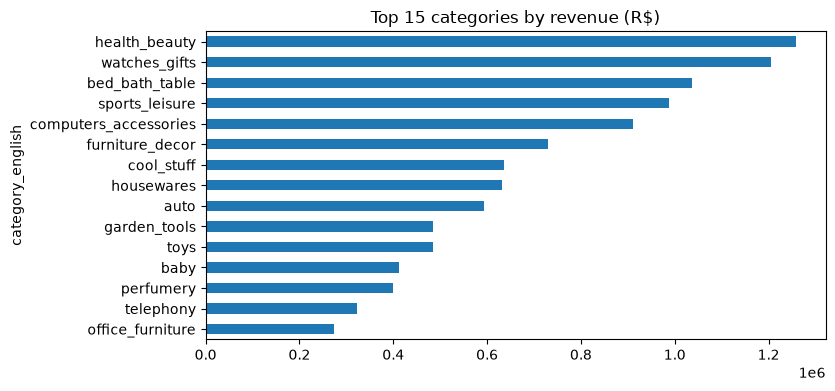

In [7]:
cats.head(15).revenue.plot(kind='barh', figsize=(8, 4), title='Top 15 categories by revenue (R$)').invert_yaxis()

## Zooming in on one seller

Instead of the whole marketplace, we pick one shop and pretend we're their assistant. Small enough to hold in your head, big enough to have interesting patterns. Everything after this point is scoped to just this seller.

In [8]:
SELLER = '955fee9216a65b617aa5c0531780ce60'   # Seller ...ce60, the UI signs in as this seller
mine   = items[(items.seller_id == SELLER) & ~items.order_status.isin(['canceled', 'unavailable'])]
seller_row = sellers[sellers.seller_id == SELLER].iloc[0]
print(f'Seller           : ...{SELLER[-4:]}   ({seller_row.city}, {seller_row.state})')
print(f'Active order lines : {len(mine):,}')
print(f'Distinct orders    : {mine.order_id.nunique():,}')
print(f'Categories sold in : {mine.category_english.nunique()}')
print(f'First / last order : {mine.purchase_date.min().date()}  →  {mine.purchase_date.max().date()}')
print(f'Lifetime revenue   : R$ {mine.price.sum():,.2f}')

Seller           : ...ce60   (sao paulo, SP)
Active order lines : 1,498
Distinct orders    : 1,286
Categories sold in : 23
First / last order : 2017-07-24  →  2018-08-28
Lifetime revenue   : R$ 135,159.70


In [9]:
# Which categories this seller actually sells in. Only these will resolve to a real number.
mine.groupby('category_english').agg(orders=('order_id', 'nunique'),
                                     revenue=('price', 'sum')).sort_values('revenue', ascending=False).head(10)

,orders,revenue
category_english,,
furniture_decor,439,38868.90
housewares,180,30844.00
sports_leisure,121,15865.89
health_beauty,112,11967.60
garden_tools,64,10321.93
cool_stuff,115,4012.50
industry_commerce_and_business,31,3760.00
stationery,46,2501.74
construction_tools_lights,41,2328.93


## What their year looks like

Revenue per month. There's a clear ramp through the first half of 2018 and a drop in summer. If someone asks "how did I do last month" or "this year", these are the shapes behind the numbers.

In [10]:
monthly = mine.assign(month=mine.purchase_date.dt.to_period('M')) \
              .groupby('month').agg(orders=('order_id', 'nunique'), revenue=('price', 'sum'))
print(monthly.tail(12).assign(revenue=lambda d: d.revenue.map('R$ {:>10,.2f}'.format)).to_string())

         orders        revenue
month                         
2017-09      26  R$   2,101.36
2017-10      18  R$   1,910.00
2017-11      50  R$   5,046.87
2017-12      60  R$   6,056.84
2018-01     230  R$  16,991.33
2018-02      88  R$   8,685.08
2018-03     154  R$  13,982.41
2018-04     204  R$  21,794.60
2018-05     202  R$  28,060.30
2018-06      99  R$  13,912.77
2018-07      60  R$   6,597.80
2018-08      67  R$   7,304.57


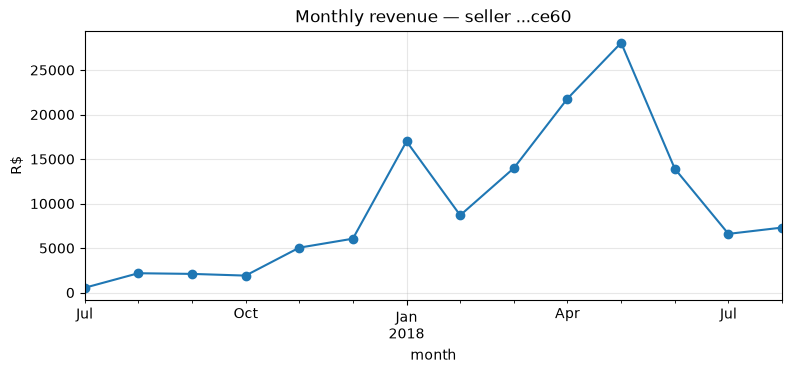

In [11]:
ax = monthly.revenue.plot(figsize=(9, 3.5), marker='o', title='Monthly revenue (seller ...ce60)')
ax.set_ylabel('R$'); ax.grid(alpha=0.3)

## What "high value" means for this shop

A quick look at the price distribution so nothing is a surprise later. Median order line is around R$ 70; a handful cross R$ 300.

In [12]:
print(mine.price.describe().to_string())
print(f'\nOrder lines priced >= R$ 300 : {(mine.price >= 300).sum()}   ({(mine.price >= 300).mean()*100:.1f}%)')
print(f'Order lines priced >= R$ 150 : {(mine.price >= 150).sum()}   ({(mine.price >= 150).mean()*100:.1f}%)')

count    1498.000000
mean       90.226769
std        83.893907
min        10.000000
25%        45.000000
50%        69.900000
75%        98.000000
max       750.000000

Order lines priced >= R$ 300 : 57   (3.8%)
Order lines priced >= R$ 150 : 170   (11.3%)


<Axes: title={'center': 'Price per order line , seller ...ce60 (clipped at R$ 800)'}, ylabel='Frequency'>

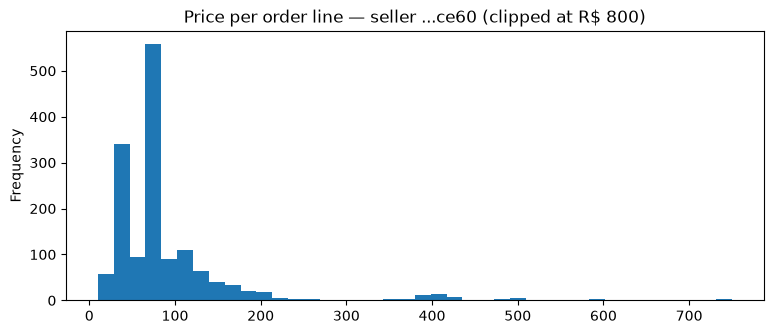

In [13]:
mine.price.clip(upper=800).plot(kind='hist', bins=40, figsize=(9, 3.5),
                                title='Price per order line, seller ...ce60 (clipped at R$ 800)')

## What the assistant will say

Below is one small pandas query per question the assistant handles. Same seller, same dates, same filter on order status. Run them and you know exactly what the chat will answer when someone types the equivalent question.

In [14]:
# Chip A · 'How many orders did I get last month?'
# 'last month' resolves relative to today (2018-09-01) → August 2018.
aug = mine[(mine.purchase_date >= '2018-08-01') & (mine.purchase_date <= '2018-08-31')]
print(f'Expected reply : "You had {aug.order_id.nunique():,} orders for all your products in August 2018."')

Expected reply : "You had 67 orders for all your products in August 2018."


In [15]:
# Chip A · 'What was my revenue in March 2018?'
mar = mine[(mine.purchase_date >= '2018-03-01') & (mine.purchase_date <= '2018-03-31')]
print(f'Expected reply : "Your revenue for all your products in March 2018 was R$ {mar.price.sum():,.2f}."')

Expected reply : "Your revenue for all your products in March 2018 was R$ 13,982.41."


In [16]:
# Chip A · 'How many sports orders did I get in 2018?'
# 'sports' → sports_leisure via canonical/vocabulary.json.
sp = mine[(mine.category_english == 'sports_leisure') & (mine.purchase_date.dt.year == 2018)]
print(f'Expected reply : "You had {sp.order_id.nunique()} orders for sports leisure in 2018."')

Expected reply : "You had 105 orders for sports leisure in 2018."


In [17]:
# Chip A · 'Show my top 3 categories by revenue this year'
y18 = mine[mine.purchase_date.dt.year == 2018]
top3 = y18.groupby('category_english').price.sum().sort_values(ascending=False).head(3)
print('Expected reply lists (in order):')
for i, (cat, rev) in enumerate(top3.items(), 1):
    print(f'  {i}. {cat.replace("_", " "):<30} R$ {rev:,.2f}')

Expected reply lists (in order):
  1. furniture decor                R$ 29,778.90
  2. housewares                     R$ 26,110.00
  3. sports leisure                 R$ 14,796.46


In [18]:
# Chip ? · 'How am I doing this year?' The app asks 'which metric?'.
# Whatever the audience picks, this year = 2018-01-01 → 2018-08-31, all products.
print(f'If "the number of orders" → {y18.order_id.nunique():,} orders in 2018 so far')
print(f'If "your revenue"         → R$ {y18.price.sum():,.2f} in 2018 so far')
print(f'If "items sold"           → {len(y18):,} items in 2018 so far')

If "the number of orders" → 1,104 orders in 2018 so far
If "your revenue"         → R$ 117,328.86 in 2018 so far
If "items sold"           → 1,274 items in 2018 so far


In [19]:
# Chip C · 'Why did my sales drop in March?' The app refuses the causal question,
# but shows March 2018 revenue as verifiable context.
print(f'Context number the app WILL show   : R$ {mar.price.sum():,.2f} (March 2018 revenue, same as chip A #2)')
print(f'Causal answer the app WILL NOT give: refused. The data has no causal signal to read.')

Context number the app WILL show   : R$ 13,982.41 (March 2018 revenue, same as chip A #2)
Causal answer the app WILL NOT give: refused , the data has no causal signal to read.


In [20]:
# Chip R · "Show me all sellers' orders last month" AND 'How does my revenue compare to other sellers?'
# The app refuses BEFORE running any SQL. Nothing to compute. Show it to the audience
# so they see the guardrail fires before the model is ever consulted.
aug_all = items[(items.purchase_date >= '2018-08-01') & (items.purchase_date <= '2018-08-31') &
                ~items.order_status.isin(['canceled', 'unavailable'])]
print(f'Would leak (if the guardrail failed): {aug_all.seller_id.nunique():,} sellers, {aug_all.order_id.nunique():,} orders in August 2018')
print(f'What the app actually returns       : "This portal only shows your own orders."')

Would leak (if the guardrail failed): 1,258 sellers, 6,388 orders in August 2018
What the app actually returns       : "This portal only shows your own orders."


### Chip B · one small LLM call

The B chip demonstrates the only route where a language model is used. Rules resolve every slot they can. One slot, the product term, is left for the LLM to fill from a short list of candidate categories. If the model is confident, the same approved SQL template as Route A runs. If not, the pipeline safely refuses without inventing a number.

In [21]:
# Chip B · 'How many bicycle helmet orders did I get in 2018?'
# Rules cannot map "bicycle helmet" to a category, so Route B fires and the LLM picks from a shortlist.
# On the demo laptop the shortlist top is sports_leisure. That is the category the model resolves to.
sl_2018 = mine[(mine.category_english == "sports_leisure") & (mine.purchase_date.dt.year == 2018)]
print(f'Expected reply : "You had {sl_2018.order_id.nunique()} orders for sports leisure in 2018."')
print(f'(Route B on the UI · 1 LLM call · ~290 tokens · answer validated in code before the SQL runs.)')

Expected reply : "You had 105 orders for sports leisure in 2018."
(Route B on the UI · 1 LLM call · ~290 tokens · answer validated in code before the SQL runs.)


## The five activities, in numbers

Each activity below teaches the assistant one new business word (a slang term, a category bundle, a promotional week, a price band, or a topic to refuse). The numbers here are what should come back after the entry lands.

In [22]:
y17 = mine[mine.purchase_date.dt.year == 2017]
print(f'2017 baseline (unfiltered) : {y17.order_id.nunique()} orders across all products')

2017 baseline (unfiltered) : 182 orders across all products


In [23]:
# Activity 1 · warpaint → health_beauty (2017)
n = y17[y17.category_english == 'health_beauty'].order_id.nunique()
print(f'AFTER adding "warpaint" to vocabulary.json → "You had {n} orders for health beauty in 2017."')

AFTER adding "warpaint" to vocabulary.json → "You had 4 orders for health beauty in 2017."


In [24]:
# Activity 2 · living room setup = 3 categories (2017)
LIVING = ['furniture_living_room', 'furniture_decor', 'home_confort']
n = len(y17[y17.category_english.isin(LIVING)])   # items, not distinct orders
print(f'AFTER adding "living room setup" to groups.json → "You sold {n} items of furniture decor, furniture living room, home confort in 2017."')

AFTER adding "living room setup" to groups.json → "You sold 118 items of furniture decor, furniture living room, home confort in 2017."


In [25]:
# Activity 3 · founders week = Oct 1 → Oct 7
for year in (2017, 2018):
    fw = mine[(mine.purchase_date >= f'{year}-10-01') & (mine.purchase_date <= f'{year}-10-07')]
    n  = fw.order_id.nunique()
    print(f'AFTER adding "founders week" to calendar.json → "You had {n} orders for all your products from 1 Oct {year} to 7 Oct {year}."')

AFTER adding "founders week" to calendar.json → "You had 5 orders for all your products from 1 Oct 2017 to 7 Oct 2017."
AFTER adding "founders week" to calendar.json → "You had 0 orders for all your products from 1 Oct 2018 to 7 Oct 2018."


In [26]:
# Activity 4 · mega orders = price >= 300 (2017)
for threshold in (300, 150):
    n = y17[y17.price >= threshold].order_id.nunique()
    print(f'AFTER adding "mega orders" (price >= {threshold}) to amounts.json → "You had {n} mega orders in 2017. (price >= R$ {threshold:.2f})"')

AFTER adding "mega orders" (price >= 300) to amounts.json → "You had 2 mega orders in 2017. (price >= R$ 300.00)"
AFTER adding "mega orders" (price >= 150) to amounts.json → "You had 13 mega orders in 2017. (price >= R$ 150.00)"


In [27]:
# Activity 5 · warranty is out of scope. The DB has no such column.
print(f'Columns in items table: {list(items.columns)}')
print(f'Any warranty column?    {any("warranty" in c for c in items.columns)}')
print()
print('AFTER adding "warranty" to unsupported.json → the app refuses at the scope gate, before any SQL.')

Columns in items table: ['order_id', 'seller_id', 'category_english', 'price', 'freight_value', 'order_status', 'purchase_ts', 'purchase_date']
Any warranty column?    False

AFTER adding "warranty" to unsupported.json → the app refuses at the scope gate, before any SQL.


---
## That's the tour

Everything above is a pandas print. No engine, no model. If the chat gives a different number for the same question, one of three things changed: which seller is signed in, the date treated as today, or the status filter.